exploration of data from [Epifanio et al. 2020](https://cp.copernicus.org/articles/16/2431/2020/)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hydra import initialize, compose
from pathlib import Path

# load data

In [28]:
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(config_name="config")
data_dir = Path(cfg.paths.observations_root)

obs_epifanio = pd.read_csv(
    data_dir / "raw/sp19methane.txt",
    sep="\t",
    comment="#",
    header=None,
)

obs_epifanio.columns = ["depth_m", "age_calBP", "ch4"]

# Drop rows where depth_m is not numeric
obs_epifanio = obs_epifanio[
    pd.to_numeric(obs_epifanio["depth_m"], errors="coerce").notna()
].astype(float)

# Change BP age to gas age (CE)
obs_epifanio["gas_age"] = 1950 - obs_epifanio["age_calBP"]

Text(0, 0.5, 'Methane (ppb)')

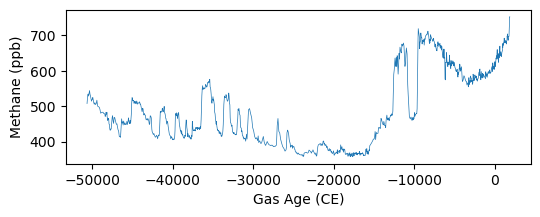

In [30]:
## plot all data
fig, ax = plt.subplots(1, 1, figsize=(6, 2))
ax.plot(
    obs_epifanio["gas_age"],
    obs_epifanio["ch4"],
    color="tab:blue",
    lw=0.5,
)

ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("Methane (ppb)")

# Compare resolution to GISP2 data

In [31]:
from methane_noise_forcing import io

site = "wdc06a"
obs_wdc06a = io.load_observational_data(site, **cfg.io[site].input)

2025-12-22 09:59:25,268 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv


WDC06A observations: 389
Epifanio et al. 2020 observations: 168


Text(0, 0.5, 'Methane (ppb)')

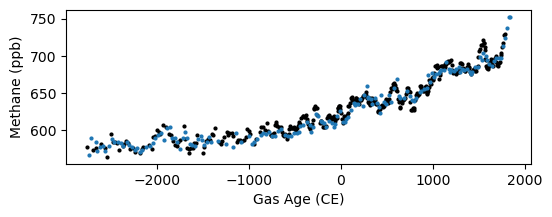

In [37]:
## plot Epifanio vs. WDC06A
# mask Epifanio data to WDC06A age range
age_min = obs_wdc06a["gas_age"].min()
mask = obs_epifanio["gas_age"] >= age_min
obs_epifanio_masked = obs_epifanio[mask]

fig, ax = plt.subplots(1, 1, figsize=(6, 2))

# wdc06a data, black dots
ax.plot(
    obs_wdc06a["gas_age"],
    obs_wdc06a["ch4"],
    "o",
    color="black",
    markersize=2,
    label="WDC06A",
)

# epifanio data, blue dots
ax.plot(
    obs_epifanio_masked["gas_age"],
    obs_epifanio_masked["ch4"],
    "o",
    color="tab:blue",
    markersize=2,
    label="Epifanio et al. 2020",
)

# print number of observations in each dataset
n_wdc06a = len(obs_wdc06a)
n_epifanio = len(obs_epifanio_masked)
print(f"WDC06A observations: {n_wdc06a}")
print(f"Epifanio et al. 2020 observations: {n_epifanio}")

ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("Methane (ppb)")